# Análise Exploratória - Catapulta DOE

Este notebook realiza uma análise exploratória dos dados do arquivo `catapulta_doe.csv`.

Objetivos:
- Inspecionar estrutura dos dados
- Avaliar qualidade dos dados
- Gerar estatísticas descritivas
- Analisar correlações
- Identificar fatores associados à variável resposta `distancia`


In [6]:
import sys
from pathlib import Path

ROOT = Path().resolve().parent

sys.path.append(str(ROOT))

import matplotlib.pyplot as plt

from src.data_loader import get_csv, load_csv

df = load_csv(get_csv()[0])

print(df.shape)
df.head()


(96, 8)


,ensaio,replica,release_angle,firing_angle,cup_elevation,pin_elevation,bungee_elevation,distancia
0,1,3,176,90,211,100,100,86.24
1,2,3,156,140,290,100,200,129.61
2,3,3,156,140,211,100,200,70.52
3,4,3,176,140,290,200,100,204.86
4,5,2,156,90,211,100,200,69.54


In [ ]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ensaio            96 non-null     int64  
 1   replica           96 non-null     int64  
 2   release_angle     96 non-null     int64  
 3   firing_angle      96 non-null     int64  
 4   cup_elevation     96 non-null     int64  
 5   pin_elevation     96 non-null     int64  
 6   bungee_elevation  96 non-null     int64  
 7   distancia         96 non-null     float64
dtypes: float64(1), int64(7)
memory usage: 6.1 KB


In [ ]:
df.describe()

,ensaio,replica,release_angle,firing_angle,cup_elevation,pin_elevation,bungee_elevation,distancia
count,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000
mean,48.500000,2.000000,166.000000,115.000000,250.500000,150.000000,150.000000,149.106667
std,27.856777,0.820783,10.052494,25.131234,39.707351,50.262469,50.262469,81.581270
min,1.000000,1.000000,156.000000,90.000000,211.000000,100.000000,100.000000,21.040000
25%,24.750000,1.000000,156.000000,90.000000,211.000000,100.000000,100.000000,79.570000
50%,48.500000,2.000000,166.000000,115.000000,250.500000,150.000000,150.000000,145.575000
75%,72.250000,3.000000,176.000000,140.000000,290.000000,200.000000,200.000000,199.977500
max,96.000000,3.000000,176.000000,140.000000,290.000000,200.000000,200.000000,345.450000


## Valores ausentes

In [ ]:
df.isna().sum()

ensaio              0
replica             0
release_angle       0
firing_angle        0
cup_elevation       0
pin_elevation       0
bungee_elevation    0
distancia           0
dtype: int64

## Correlação

In [ ]:
corr = df.corr(numeric_only=True)

corr["distancia"].sort_values(ascending=False)


distancia           1.000000
cup_elevation       0.604846
release_angle       0.550745
bungee_elevation    0.434828
ensaio              0.205384
pin_elevation       0.192139
replica             0.007456
firing_angle       -0.140549
Name: distancia, dtype: float64

> Aparentemente, os valores mais relacionados à distancia são a Posição vertical da concha (`cup_elevation`), Ângulo de soltura do braço (`release_angle`) e a Posição vertical do bungee (`bungee_elevation`).

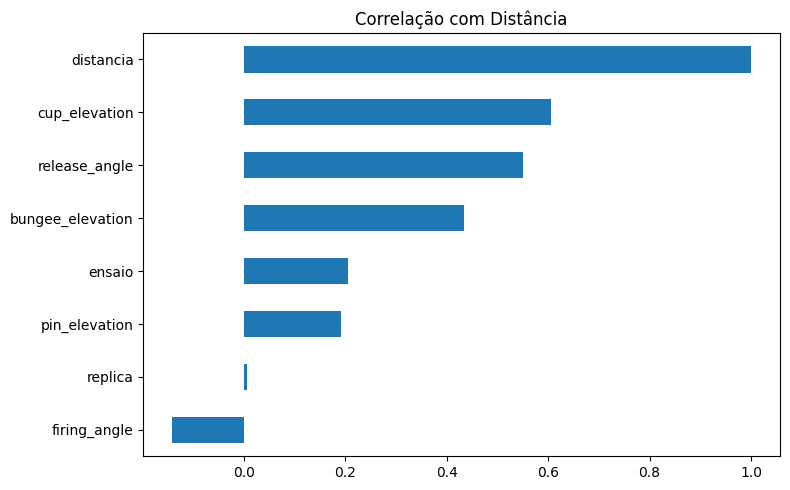

In [ ]:
plt.figure(figsize=(8,5))
corr["distancia"].sort_values().plot(kind="barh")
plt.title("Correlação com Distância")
plt.tight_layout()
plt.show()
